# Dense And Sparse Correspondence
In this tutorial we show how DINOv3 features can be used to establish correspondences between two objects.

### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:
- `local` if `DINOV3_LOCATION` environment variable was set to work with a local version of DINOv3 repository;
- `github` if the code should be loaded via torch hub.

In [1]:
import json
import pickle
import os
from pathlib import Path

import numpy as np
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm

from origami_texturing.paths import EXTERNAL_DIR, NOTEBOOKS_DIR, INPUTS_DIR, RAW_DATA_DIR

DINOV3_LOCAL_LOCATION = EXTERNAL_DIR / "dinov3"
DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"

if os.getenv("DINOV3_LOCATION") is not None:
    DINOV3_LOCATION = os.getenv("DINOV3_LOCATION")
elif DINOV3_LOCAL_LOCATION.exists():
    DINOV3_LOCATION = str(DINOV3_LOCAL_LOCATION)
else:
    DINOV3_LOCATION = DINOV3_GITHUB_LOCATION

print(f"DINOv3 location set to {DINOV3_LOCATION}")

DINOv3 location set to C:\Users\morph\GitHub\origami-texturing\external\dinov3


### Model Loading
We load the DINOv3 ViT-H+ model. Feel free to try other DINOv3 models as well!

In [2]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_NAME = MODEL_DINOV3_VITHP

from origami_texturing.paths import MODELS_DIR
WEIGHTS = str(MODELS_DIR / "dinov3" / "dinov3_vith16plus.pth")

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model="dinov3_vith16plus",
    source="local",
    weights=WEIGHTS,
)
model.cuda()

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x SelfAttentionBlock(
      (norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1280, out_features=3840, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (mlp): SwiGLUFFN(
        (w1): Linear(in_features=1280, out_features=5120, bias=True)
        (w2): Linear(in_features=1280, out_features=5120, bias=True)
        (w3): Linear(in_features=5120, out_features=1280, bias=True)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerNorm((

### Data Loading
Now that we have the model set up, let's load the two input images and the local foreground classifier.

The foreground masks are predicted from DINOv3 patch features later in the notebook, instead of being downloaded as precomputed mask images.


In [3]:
target_image_path = RAW_DATA_DIR / "dove-wingup.png"
reference_image_path = INPUTS_DIR / "lovebird-wingup.png"
fg_classifier_path = NOTEBOOKS_DIR / "fg_classifier.pkl"


def load_image_from_path(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")


def load_foreground_classifier(path: Path):
    with open(path, "rb") as file:
        return pickle.load(file), path


target_image = load_image_from_path(target_image_path)
reference_image = load_image_from_path(reference_image_path)
clf, fg_classifier_path = load_foreground_classifier(fg_classifier_path)

print(f"Loaded target image from {target_image_path}")
print(f"Loaded reference image from {reference_image_path}")
print(f"Loaded foreground classifier from {fg_classifier_path}")


Loaded target image from C:\Users\morph\GitHub\origami-texturing\data\raw\dove-wingup.png
Loaded reference image from C:\Users\morph\GitHub\origami-texturing\inputs\lovebird-wingup.png
Loaded foreground classifier from C:\Users\morph\GitHub\origami-texturing\notebooks\fg_classifier.pkl


Let's visualize the two input images:


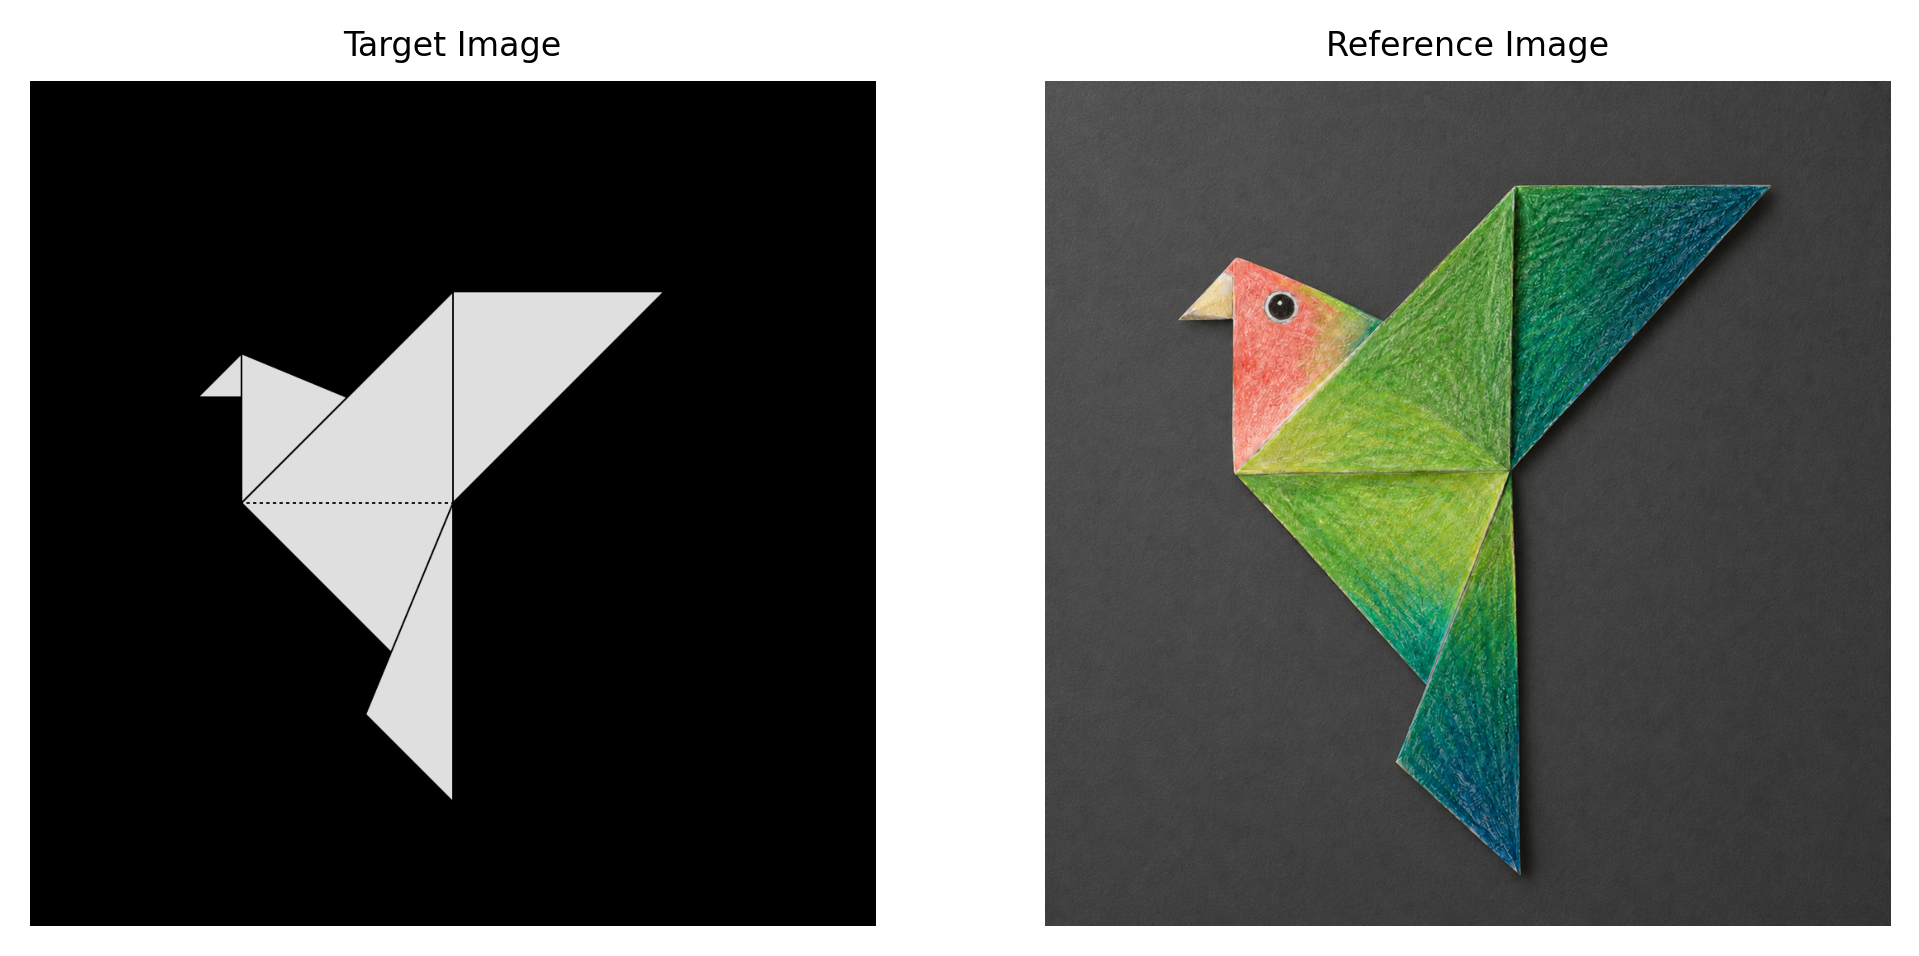

In [4]:
plt.figure(figsize=(8, 4), dpi=300)

for j, image in enumerate([target_image, reference_image]):
    plt.subplot(1, 2, j + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(["Target Image", "Reference Image"][j], fontsize=8)

plt.show()


### Data Transforms

Since our models run with a patch size of 16, we resize each image such that it aligns well with the 16x16 grid. The classifier then predicts one foreground probability per DINOv3 patch.


In [5]:
PATCH_SIZE = 16
IMAGE_SIZE = 1024

# image resize transform to dimensions divisible by patch size
def resize_transform(
    image: Image.Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(image, (h_patches * patch_size, w_patches * patch_size)))


def patch_scores_to_alpha_image(patch_scores: torch.Tensor, image_size: tuple[int, int]) -> Image.Image:
    width, height = image_size
    alpha = TF.resize(
        patch_scores.unsqueeze(0),
        (height, width),
        interpolation=TF.InterpolationMode.BILINEAR,
    ).squeeze(0)
    alpha_np = (alpha.clamp(0, 1).numpy() * 255).astype(np.uint8)
    return Image.fromarray(alpha_np, mode="L")


### Extracting Features And Segmenting Foreground
Now we extract DINOv3 patch features for the two images, then run `fg_classifier.pkl` on those features to predict foreground probabilities.

Each tensor of patch features has shape `[D, H, W]`, where `D` is feature dimensionality, and `H` and `W` are image dimensions in the number of patches. Each foreground mask has shape `[H, W]`.


In [6]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

patch_mask_values = []
patch_features = []

with torch.inference_mode():
    with torch.autocast(device_type="cuda", dtype=torch.float32):
        for image in tqdm([target_image, reference_image], desc="Processing images"):
            image_resized = resize_transform(image)
            image_resized = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            image_resized = image_resized.unsqueeze(0).cuda()

            feats = model.get_intermediate_layers(image_resized, n=range(n_layers), reshape=True, norm=True)
            feature_map = feats[-1].squeeze().detach().cpu()
            dim, h_patches, w_patches = feature_map.shape
            patch_features.append(feature_map)

            feature_matrix = feature_map.view(dim, -1).permute(1, 0).numpy()
            expected_dim = getattr(clf, "n_features_in_", feature_matrix.shape[1])
            if feature_matrix.shape[1] != expected_dim:
                raise ValueError(
                    f"Foreground classifier expects {expected_dim} features, "
                    f"but {MODEL_NAME} produced {feature_matrix.shape[1]}. "
                    "Use the same DINOv3 backbone that was used to train fg_classifier.pkl."
                )

            fg_scores = clf.predict_proba(feature_matrix)[:, 1]
            fg_scores = torch.from_numpy(fg_scores).float().view(h_patches, w_patches)
            patch_mask_values.append(fg_scores)


Processing images: 100%|██████████| 2/2 [00:01<00:00,  1.64it/s]


Let's visualize the foreground/background composites:


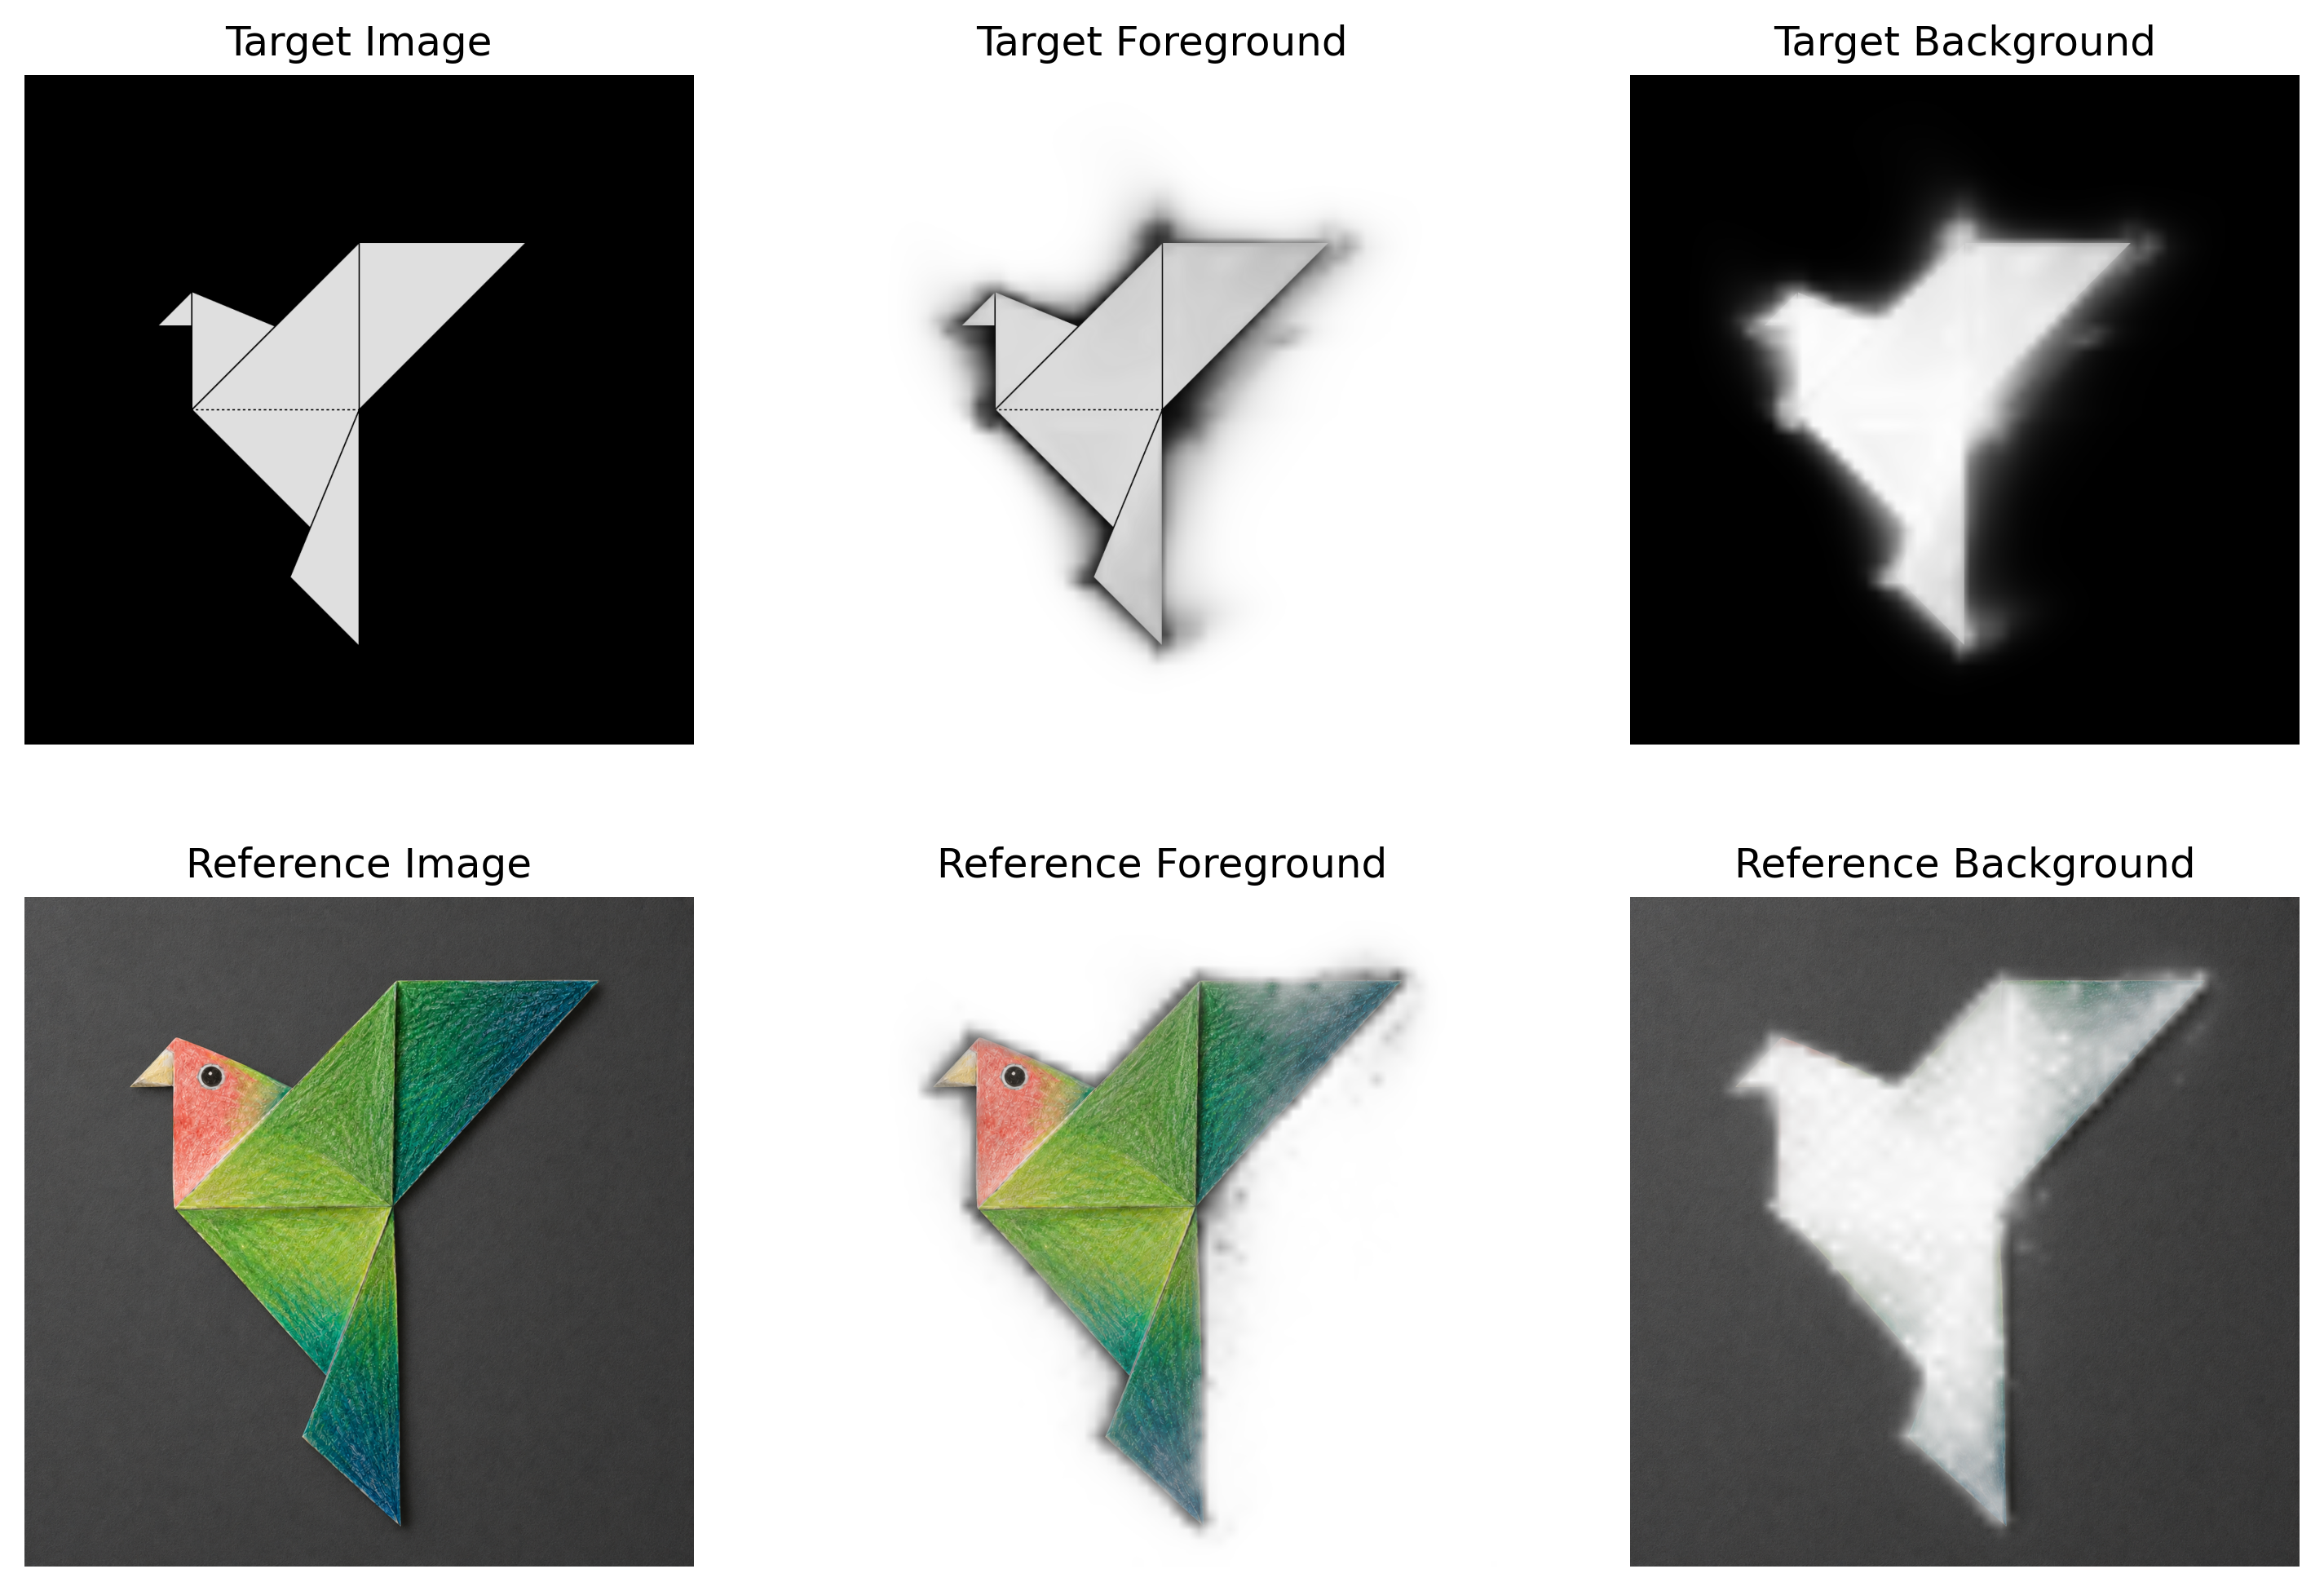

In [7]:
plt.figure(figsize=(12, 8), dpi=300)

for j, (image, patch_scores) in enumerate(zip([target_image, reference_image], patch_mask_values)):
    image_rgba = image.convert("RGBA")
    transparent = Image.new("RGBA", image.size, (0, 0, 0, 0))
    alpha = patch_scores_to_alpha_image(patch_scores, image.size)
    foreground = Image.composite(image_rgba, transparent, alpha)
    background = Image.composite(image_rgba, transparent, Image.eval(alpha, lambda a: 255 - a))

    label_prefix = ["Target", "Reference"][j]
    data_to_show = [image, foreground, background]
    data_labels = [f"{label_prefix} Image", f"{label_prefix} Foreground", f"{label_prefix} Background"]

    for i, data in enumerate(data_to_show):
        plt.subplot(2, len(data_to_show), len(data_to_show) * j + i + 1)
        plt.imshow(data)
        plt.axis("off")
        plt.title(data_labels[i], fontsize=12)

plt.show()


### Matching Patches

For each patch within the foreground object in the target image, we search for the closest patch in the reference image using [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) between patch features. We select correspondences only for foreground objects.

In [8]:
MASK_FG_THRESHOLD = 0.5

patch_features[0] = F.normalize(patch_features[0], p=2, dim=0)
patch_features[1] = F.normalize(patch_features[1], p=2, dim=0)

heatmaps = torch.einsum(
    "k f, f h w -> k h w",
    patch_features[0].view(dim, -1).permute(1, 0),
    patch_features[1],
)

# compute 2D patch locations in the target image
n_patches_target = patch_features[0].shape[1] * patch_features[0].shape[2]
patch_indices_target = torch.arange(n_patches_target)
locs_2d_target = (
    torch.stack(
        (
            patch_indices_target // patch_features[0].shape[2],  # row
            patch_indices_target % patch_features[0].shape[2]    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# compute the corresponding 2D patch locations in the reference image
patch_indices_reference = torch.flatten(heatmaps, start_dim=-2).argmax(dim=-1)
locs_2d_reference = (
    torch.stack(
        (
            patch_indices_reference // patch_features[1].shape[2],  # row
            patch_indices_reference % patch_features[1].shape[2]    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# foreground patches mask in the target image
patches_target_fg_selection = (patch_mask_values[0].view(-1) > MASK_FG_THRESHOLD)
# target image patches mask for patches that map to a foreground patch in the reference image
patches_reference_fg_selection = (patch_mask_values[1].view(-1)[patch_indices_reference] > MASK_FG_THRESHOLD)
# select foreground target image patches that map to foreground reference image patches
patches_fg_selection = (patches_target_fg_selection * patches_reference_fg_selection)

# select (row, col) coordinates for the matched patches
locs_2d_target_fg = locs_2d_target[patches_fg_selection, :]
locs_2d_reference_fg = locs_2d_reference[patches_fg_selection, :]

### Dense Correspondence
We now show dense correspondences between patches using the color space estimated through PCA over foreground patches in the target image. Closer colors correspond to more similar patches.

In [9]:
pca = PCA(n_components=3, whiten=True)
fg_patches_target = patch_features[0].view(dim, -1).permute(1, 0)[patches_fg_selection]
pca.fit(fg_patches_target)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",True
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD s

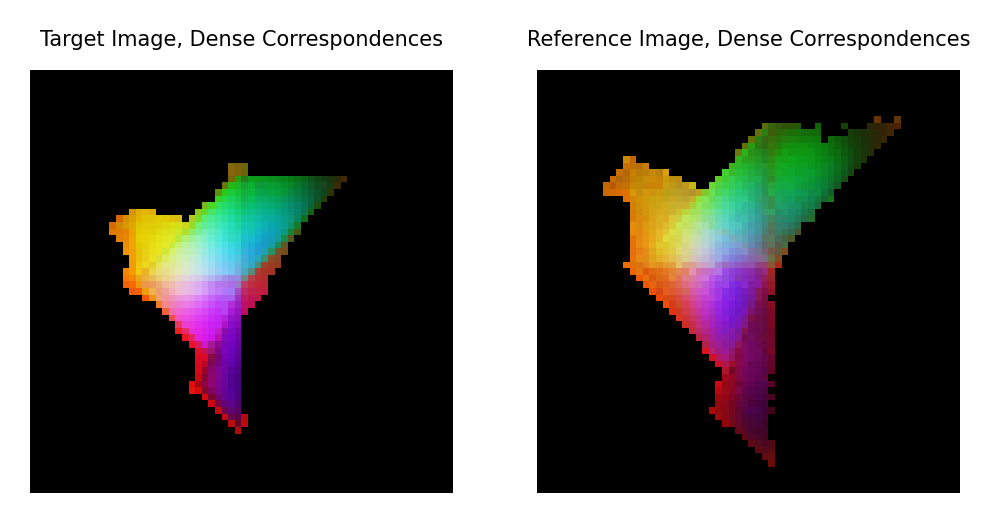

In [10]:
# get colors for the target image
h_patches_target = patch_features[0].shape[1]
w_patches_target = patch_features[0].shape[2]
x_target = patch_features[0].view(dim, -1).permute(1, 0)
projected_image_target = torch.from_numpy(
    pca.transform(x_target.numpy())
).view(h_patches_target, w_patches_target, 3)
# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image_target = torch.nn.functional.sigmoid(projected_image_target.mul(2.0)).permute(2, 0, 1)

# get colors for the reference image
h_patches_reference = patch_features[1].shape[1]
w_patches_reference = patch_features[1].shape[2]
x_reference = patch_features[1].view(dim, -1).permute(1, 0)
projected_image_reference = torch.from_numpy(
    pca.transform(x_reference.numpy())
).view(h_patches_reference, w_patches_reference, 3)
projected_image_reference = torch.nn.functional.sigmoid(projected_image_reference.mul(2.0)).permute(2, 0, 1)

# apply foreground masks to both visualizations
projected_image_target *= (patch_mask_values[0] > MASK_FG_THRESHOLD)[None, :, :]
projected_image_reference *= (patch_mask_values[1] > MASK_FG_THRESHOLD)[None, :, :]

plt.figure(figsize=(4, 2), dpi=300)
plt.subplot(1, 2, 1)
plt.imshow(projected_image_target.permute(1, 2, 0))
plt.title("Target Image, Dense Correspondences", fontsize=5)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(projected_image_reference.permute(1, 2, 0))
plt.title("Reference Image, Dense Correspondences", fontsize=5)
plt.axis('off')
plt.show()

### Sparse Correspondence

Finally, we show the established correspondences via the sparse set of matched points.

Loaded 11 target vertices from C:\Users\morph\GitHub\origami-texturing\data\raw\dove-wingup-topology.json


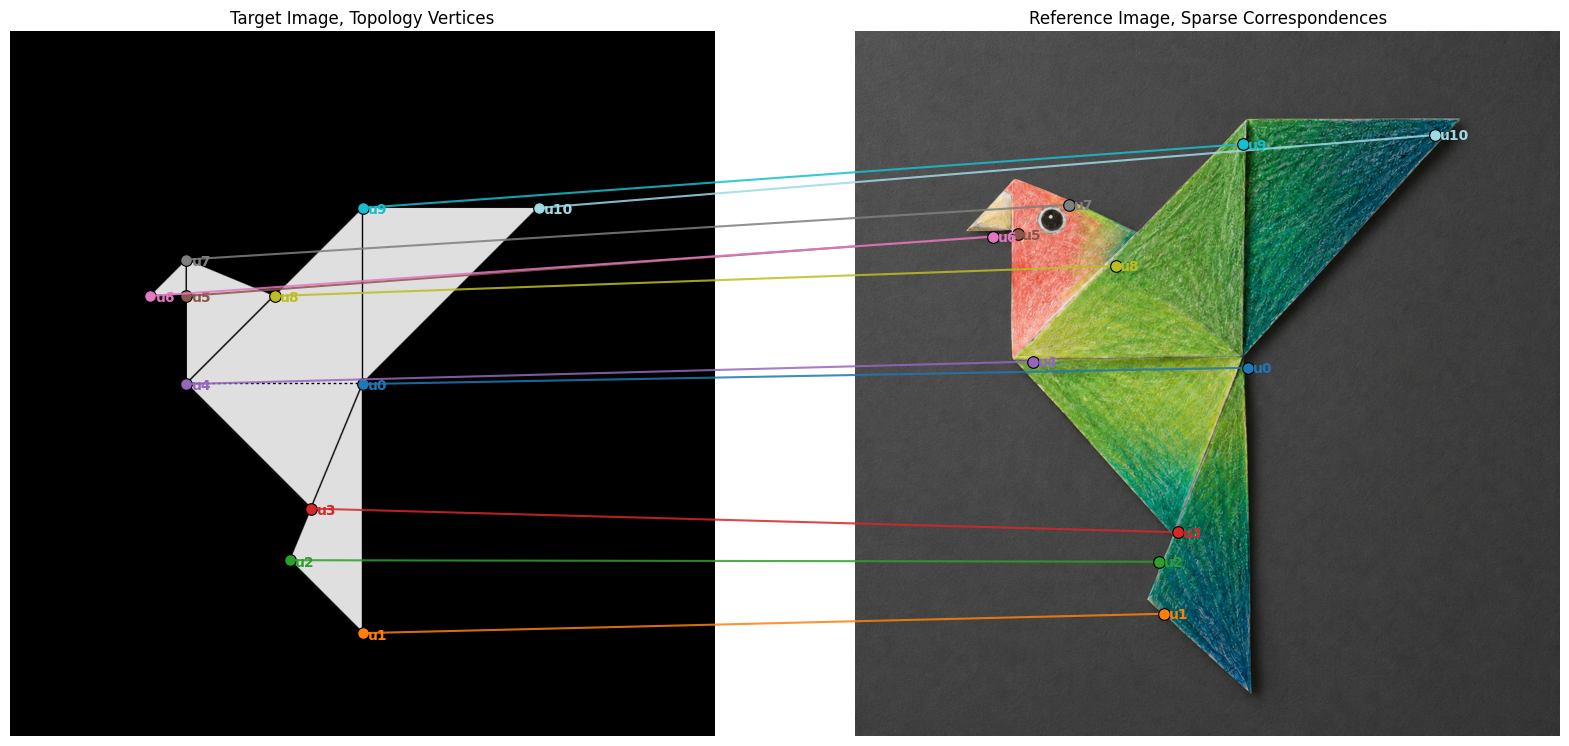

In [11]:
# image scale to go from resized patch coordinates to original image coordinates
scale_target = target_image.height / IMAGE_SIZE
scale_reference = reference_image.height / IMAGE_SIZE

target_topology_path = RAW_DATA_DIR / "dove-wingup-topology.json"
with open(target_topology_path, "r", encoding="utf-8") as file:
    target_topology = json.load(file)

topology_width, topology_height = target_topology["resolution"]
target_topology_scale_x = target_image.width / topology_width
target_topology_scale_y = target_image.height / topology_height

target_vertices = {
    vertex_id: tuple(coord)
    for vertex_id, coord in target_topology["vertices"].items()
}

target_h_patches, target_w_patches = patch_features[0].shape[1:]

reference_heatmaps = heatmaps.clone()
if "patch_mask_values" in globals():
    reference_fg_mask = patch_mask_values[1] > MASK_FG_THRESHOLD
    reference_heatmaps = reference_heatmaps.masked_fill(~reference_fg_mask[None, :, :], -torch.inf)


def point_to_nearest_patch_index(row_resized: float, col_resized: float, h_patches: int, w_patches: int) -> int:
    row_patch = int(np.clip(np.round(row_resized / PATCH_SIZE - 0.5), 0, h_patches - 1))
    col_patch = int(np.clip(np.round(col_resized / PATCH_SIZE - 0.5), 0, w_patches - 1))
    return row_patch * w_patches + col_patch


def refine_reference_point_from_heatmap(
    heatmap: torch.Tensor,
    window_radius: int = 2,
    temperature: float = 0.05,
) -> np.ndarray:
    if not torch.isfinite(heatmap).any():
        heatmap = torch.zeros_like(heatmap)

    best_index = torch.flatten(heatmap).argmax().item()
    best_row = best_index // heatmap.shape[1]
    best_col = best_index % heatmap.shape[1]

    row_start = max(best_row - window_radius, 0)
    row_end = min(best_row + window_radius + 1, heatmap.shape[0])
    col_start = max(best_col - window_radius, 0)
    col_end = min(best_col + window_radius + 1, heatmap.shape[1])

    local_scores = heatmap[row_start:row_end, col_start:col_end]
    finite_local_scores = torch.where(torch.isfinite(local_scores), local_scores, torch.tensor(-1e9, dtype=local_scores.dtype, device=local_scores.device))
    local_rows, local_cols = torch.meshgrid(
        torch.arange(row_start, row_end, dtype=local_scores.dtype, device=local_scores.device),
        torch.arange(col_start, col_end, dtype=local_scores.dtype, device=local_scores.device),
        indexing="ij",
    )

    weights = torch.softmax(finite_local_scores.flatten() / temperature, dim=0).reshape_as(finite_local_scores)
    row_resized = ((local_rows + 0.5) * PATCH_SIZE * weights).sum()
    col_resized = ((local_cols + 0.5) * PATCH_SIZE * weights).sum()
    return np.array([row_resized.item(), col_resized.item()])


target_vertex_ids = []
target_vertex_points_xy = []
matched_reference_points_yx = []

for vertex_id, (x_topology, y_topology) in target_vertices.items():
    x_target = x_topology * target_topology_scale_x
    y_target = y_topology * target_topology_scale_y

    row_resized = y_target / scale_target
    col_resized = x_target / scale_target
    target_patch_index = point_to_nearest_patch_index(
        row_resized,
        col_resized,
        target_h_patches,
        target_w_patches,
    )

    target_vertex_ids.append(vertex_id)
    target_vertex_points_xy.append((x_target, y_target))
    matched_reference_points_yx.append(refine_reference_point_from_heatmap(reference_heatmaps[target_patch_index]))

matched_reference_points_yx = np.array(matched_reference_points_yx)
matched_reference_points_xy = np.stack(
    (
        matched_reference_points_yx[:, 1] * scale_reference,
        matched_reference_points_yx[:, 0] * scale_reference,
    ),
    axis=1,
)
target_vertex_points_xy = np.array(target_vertex_points_xy, dtype=float)

print(f"Loaded {len(target_vertex_ids)} target vertices from {target_topology_path}")

# show original target and reference images
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(121)
ax1.imshow(target_image)
ax1.set_title("Target Image, Topology Vertices")
ax1.set_axis_off()
ax2 = fig.add_subplot(122)
ax2.imshow(reference_image)
ax2.set_title("Reference Image, Sparse Correspondences")
ax2.set_axis_off()

colors = plt.cm.tab20(np.linspace(0, 1, len(target_vertex_ids)))

for vertex_id, (target_x, target_y), (reference_x, reference_y), color in zip(
    target_vertex_ids,
    target_vertex_points_xy,
    matched_reference_points_xy,
    colors,
):
    ax1.scatter(target_x, target_y, s=70, c=[color], edgecolors="black", linewidths=0.8, zorder=3)
    ax1.text(target_x + 8, target_y + 8, vertex_id, color=color, fontsize=10, weight="bold")

    ax2.scatter(reference_x, reference_y, s=70, c=[color], edgecolors="black", linewidths=0.8, zorder=3)
    ax2.text(reference_x + 8, reference_y + 8, vertex_id, color=color, fontsize=10, weight="bold")

    con = ConnectionPatch(
        xyA=(target_x, target_y),
        xyB=(reference_x, reference_y),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color=color,
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.add_artist(con)
